# Phishing-URL Detection
In this notebook we:
1. Load our URL‐feature CSV
2. Preprocess (select features, encode labels)
3. Split into train/test sets
4. Train the model (our 6 models)
5. Evaluate with accuracy, ROC curve
6. Inspect feature importance

## Load Libraries


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, roc_auc_score, classification_report, roc_curve

## Preprocess Data

In [3]:
# Load the dataset
file_name = 'features_extracted.csv'
df = pd.read_csv(file_name)
df.head() # Display the first 5 rows of the dataset

,URL,Status,Label,Domain,Have_IP,Have_At,URL_Length_Over_54,URL_Depth,Redirect_//_Position,HTTP_In_Domain,HTTPS_In_Domain,Prefix_Suffix_Dash,DNS_Record,Domain_Age_Phishing,Subdomains_Phishing
0,nobell.it/70ffb52d079109dca5664cce6f317373782/...,Success,bad,nobell.it,0,0,1,8,0,0,0,0,1,0,0
1,www.dghjdgf.com/paypal.co.uk/cycgi-bin/webscrc...,Success,bad,www.dghjdgf.com,0,0,1,4,0,0,0,0,1,0,0
2,serviciosbys.com/paypal.cgi.bin.get-into.herf....,Success,bad,serviciosbys.com,0,0,1,11,0,0,0,0,1,0,0
3,mail.printakid.com/www.online.americanexpress....,Success,bad,mail.printakid.com,0,0,1,2,0,0,0,0,1,0,0
4,thewhiskeydregs.com/wp-content/themes/widescre...,Success,bad,thewhiskeydregs.com,0,0,1,7,1,0,0,0,1,0,0


In [4]:
# Select features and target variable
features = [
        'Have_IP','Have_At','URL_Length_Over_54','URL_Depth',
        'Redirect_//_Position','HTTP_In_Domain','HTTPS_In_Domain',
        'Prefix_Suffix_Dash','DNS_Record','Domain_Age_Phishing','Subdomains_Phishing'
    ]

target = 'Label'
x = df[features]
y = df[target].map({'bad': 0, 'good': 1}) # Encode labels as 0 and 1

## Train/Test Split

In [5]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=77)

## 1-Logistic Regression Classifier
### Training:

In [ ]:
# Create a Logistic Regression model
model = LogisticRegression(max_iter=1000, random_state=77)
# Train the model on the training data
model.fit(x_train, y_train)
print("Model trained successfully.")

Model trained successfully.


### Evaluate the Model

In [ ]:
# Make predictions on the test set
y_pred = model.predict(x_test)
# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
# Calculate confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)
# Calculate ROC-AUC score
roc_auc = roc_auc_score(y_test, y_pred)
# classification report
class_report = classification_report(y_test, y_pred, target_names=['bad', 'good'])

print(f"Accuracy: {accuracy:.4f}")
print("Confusion Matrix:")
print(conf_matrix)
print(f"ROC-AUC: {roc_auc:.4f}")
print("Classification Report:")
print(class_report)

Accuracy: 0.8327
Confusion Matrix:
[[12797 17419]
 [  792 77853]]
ROC-AUC: 0.7067
Classification Report:
              precision    recall  f1-score   support

         bad       0.94      0.42      0.58     30216
        good       0.82      0.99      0.90     78645

    accuracy                           0.83    108861
   macro avg       0.88      0.71      0.74    108861
weighted avg       0.85      0.83      0.81    108861



### Plot ROC Curve

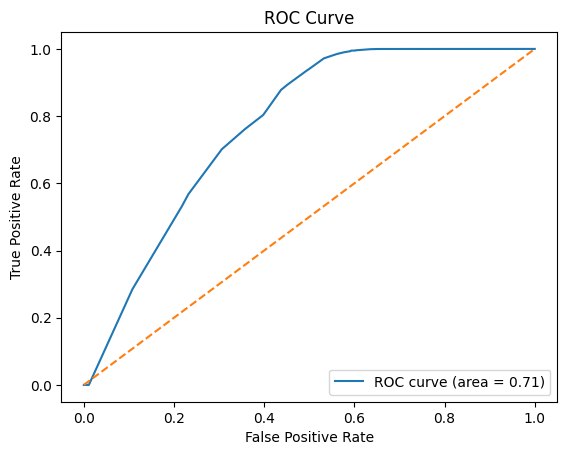

In [ ]:
y_proba = model.predict_proba(x_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_proba)
plt.figure()
plt.plot(fpr, tpr, label='ROC curve (area = {:.2f})'.format(roc_auc))
plt.plot([0, 1], [0, 1], '--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.show()

## Feature Importance

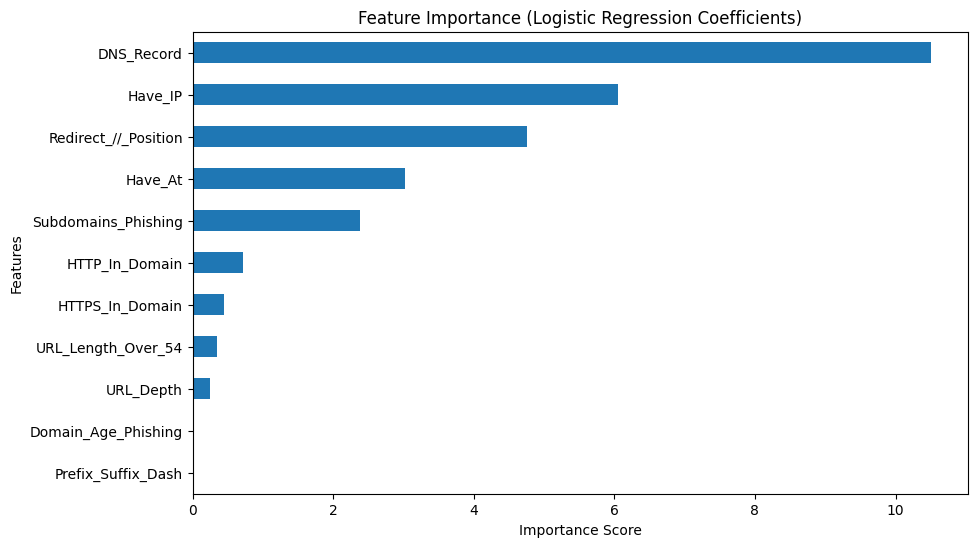

In [ ]:
importances = abs(model.coef_[0])
importance_series = pd.Series(importances, index=features).sort_values()

plt.figure(figsize=(10, 6))
importance_series.plot(kind='barh')
plt.title('Feature Importance (Logistic Regression)')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.show()


## 2- Light GBM

In [ ]:
#importing needed library
import lightgbm as lgb

#create the model
lgbmodel = lgb.LGBMClassifier()

#training
lgbmodel.fit(x_train,y_train)

#predicting
y_pred = lgbmodel.predict(x_test)

#evaluating
print("Accuracy:",accuracy_score(y_test,y_pred))

class_report = classification_report(y_test, y_pred, target_names=['bad', 'good'])

print("Classification Report:")
print(class_report)

Accuracy: 0.8379860556122027
Classification Report:
              precision    recall  f1-score   support

         bad       0.93      0.45      0.61     30216
        good       0.82      0.99      0.90     78645

    accuracy                           0.84    108861
   macro avg       0.88      0.72      0.75    108861
weighted avg       0.85      0.84      0.82    108861



### Plot ROC curve

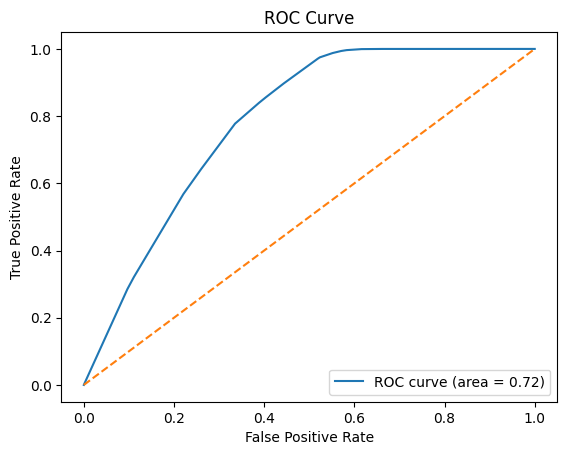

In [ ]:
#Plot ROC curve
roc_auc = roc_auc_score(y_test, y_pred)

y_proba = lgbmodel.predict_proba(x_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_proba)
plt.figure()
plt.plot(fpr, tpr, label='ROC curve (area = {:.2f})'.format(roc_auc))
plt.plot([0, 1], [0, 1], '--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.show()

### Feature Importance

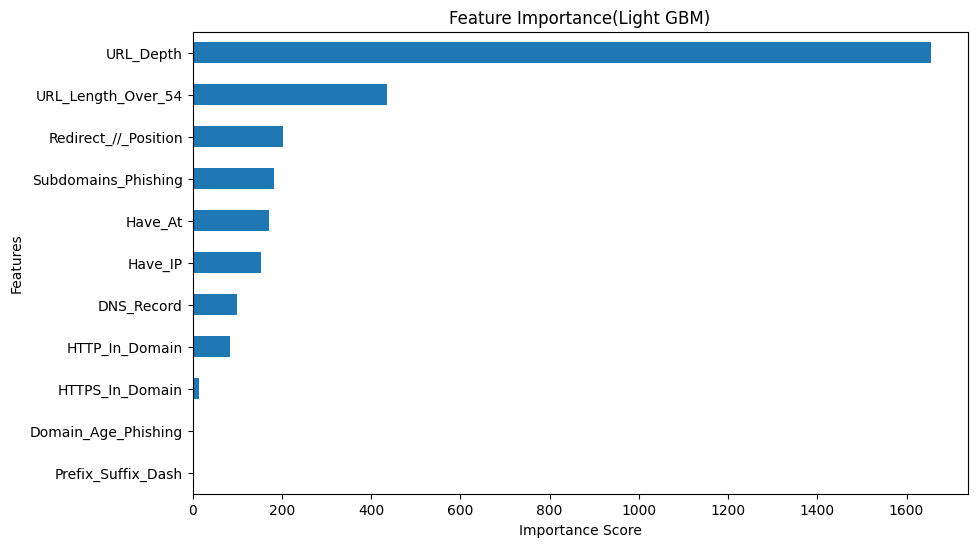

In [ ]:
# Get feature importance
importances = pd.Series(lgbmodel.feature_importances_, index=features).sort_values()

# Plot
plt.figure(figsize=(10, 6))
importances.plot(kind='barh')
plt.title('Feature Importance(Light GBM)')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.show()

## 3- SVM

### Training:


In [ ]:
# import SVC model
from sklearn.calibration import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.svm import SVC  # Support Vector Classifier
# Wrap LinearSVC
base_model = LinearSVC()
model = CalibratedClassifierCV(base_model)  # Default is sigmoid calibration
# Train the model on the training data
model.fit(x_train, y_train)
print("SVC Model trained successfully.")

SVC Model trained successfully.


### Evaluate the model


In [ ]:
# Make predictions on the test set
y_pred = model.predict(x_test)
# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
# Calculate confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)
# Calculate ROC-AUC score
roc_auc = roc_auc_score(y_test, y_pred)
# classification report
class_report = classification_report(y_test, y_pred, target_names=['bad', 'good'])

print(f"Accuracy: {accuracy:.4f}")
print("Confusion Matrix:")
print(conf_matrix)
print(f"ROC-AUC: {roc_auc:.4f}")
print("Classification Report:")
print(class_report)

Accuracy: 0.8328
Confusion Matrix:
[[12805 17411]
 [  795 77850]]
ROC-AUC: 0.7068
Classification Report:
              precision    recall  f1-score   support

         bad       0.94      0.42      0.58     30216
        good       0.82      0.99      0.90     78645

    accuracy                           0.83    108861
   macro avg       0.88      0.71      0.74    108861
weighted avg       0.85      0.83      0.81    108861



### Plot ROC curve


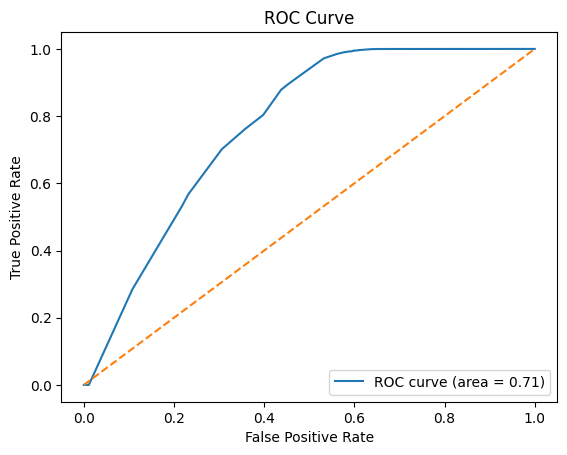

In [ ]:
##Plot ROC curve
y_proba = model.predict_proba(x_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_proba)
plt.figure()
plt.plot(fpr, tpr, label='ROC curve (area = {:.2f})'.format(roc_auc))
plt.plot([0, 1], [0, 1], '--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.show()

## 4- Decision Tree

### Training the model

In [6]:
#Import the library needed
from sklearn.tree import DecisionTreeClassifier

#Create a Decision Tree Classifier
dtc = DecisionTreeClassifier()

#Fit the model on the training data
dtc.fit(x_train, y_train)
print("Decision Tree classifier trained successfully.")


Decision Tree classifier trained successfully.


### Testing the model

In [7]:
# Make predictions
y_pred_dt = dtc.predict(x_test)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred_dt)
# Calculate confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred_dt)
# Calculate ROC-AUC score
roc_auc = roc_auc_score(y_test, y_pred_dt)
# classification report
class_report = classification_report(y_test, y_pred_dt, target_names=['bad', 'good'])

print("Accuracy: ", accuracy)
print("Confusion Matrix:")
print(conf_matrix)
print(f"ROC-AUC: {roc_auc:.4f}")
print("Classification Report:")
print(class_report)

Accuracy:  0.8379768695859858
Confusion Matrix:
[[13537 16679]
 [  959 77686]]
ROC-AUC: 0.7179
Classification Report:
              precision    recall  f1-score   support

         bad       0.93      0.45      0.61     30216
        good       0.82      0.99      0.90     78645

    accuracy                           0.84    108861
   macro avg       0.88      0.72      0.75    108861
weighted avg       0.85      0.84      0.82    108861



### Plot ROC Curve

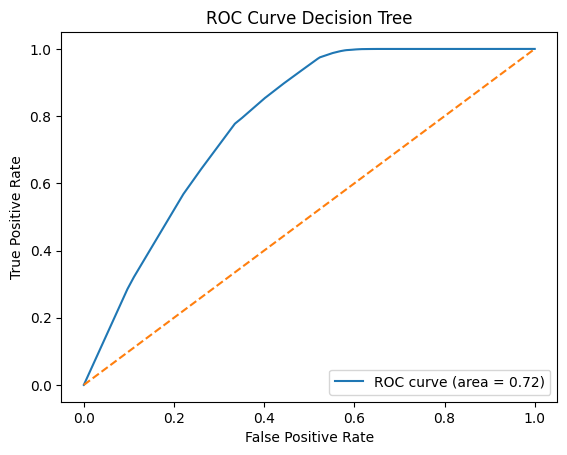

In [8]:
y_proba_dt = dtc.predict_proba(x_test)[:, 1]
fpr_dt, tpr_dt, _ = roc_curve(y_test, y_proba_dt)
plt.figure()
plt.plot(fpr_dt, tpr_dt, label='ROC curve (area = {:.2f})'.format(roc_auc))
plt.plot([0, 1], [0, 1], '--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Decision Tree')
plt.legend(loc='lower right')
plt.show()

### Feature Importance

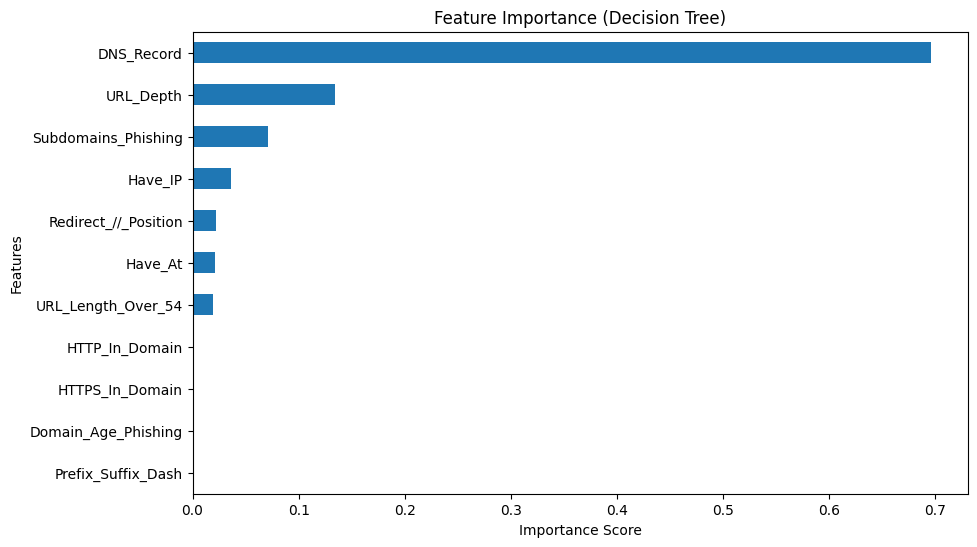

In [9]:
# Get feature importances from the model
importances = dtc.feature_importances_

# Create a Pandas Series with feature names as index
importance_series = pd.Series(importances, index=features).sort_values()

# Plot feature importance
plt.figure(figsize=(10, 6))
importance_series.plot(kind='barh')
plt.title('Feature Importance (Decision Tree)')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.show()

## 5- Random Forest
### Training

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Create a Random Forest model
rf_model = RandomForestClassifier(n_estimators=1000, random_state=77)
# Train the model
rf_model.fit(x_train, y_train)
print("Model trained successfully.")

Model trained successfully.


### Evaluate the model

In [ ]:
# Make predictions
y_pred_rf = rf_model.predict(x_test)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred_rf)
# Calculate confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred_rf)
# Calculate ROC-AUC score
roc_auc = roc_auc_score(y_test, y_pred_rf)
# classification report
class_report = classification_report(y_test, y_pred_rf, target_names=['bad', 'good'])

print(f"Accuracy: {accuracy:.4f}")
print("Confusion Matrix:")
print(conf_matrix)
print(f"ROC-AUC: {roc_auc:.4f}")
print("Classification Report:")
print(class_report)

Accuracy: 0.8380
Confusion Matrix:
[[13537 16679]
 [  959 77686]]
ROC-AUC: 0.7179
Classification Report:
              precision    recall  f1-score   support

         bad       0.93      0.45      0.61     30216
        good       0.82      0.99      0.90     78645

    accuracy                           0.84    108861
   macro avg       0.88      0.72      0.75    108861
weighted avg       0.85      0.84      0.82    108861



### Plot ROC Curve

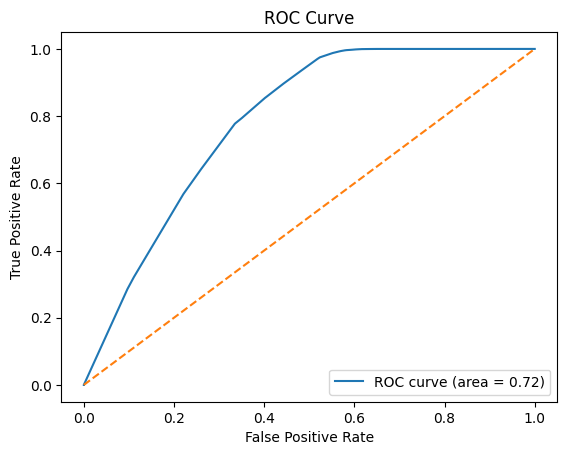

In [ ]:
y_proba_rf = rf_model.predict_proba(x_test)[:, 1]
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_proba_rf)
plt.figure()
plt.plot(fpr_rf, tpr_rf, label='ROC curve (area = {:.2f})'.format(roc_auc))
plt.plot([0, 1], [0, 1], '--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.show()

### Feature Importance

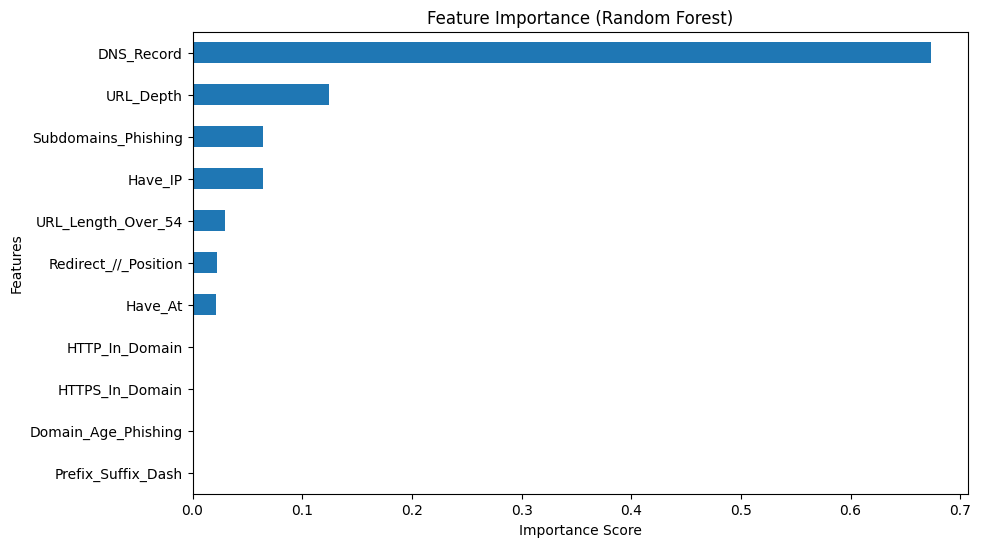

In [ ]:
# Get feature importances from the model
importances = rf_model.feature_importances_

# Create a Pandas Series with feature names as index
importance_series = pd.Series(importances, index=features).sort_values()

# Plot feature importance
plt.figure(figsize=(10, 6))
importance_series.plot(kind='barh')
plt.title('Feature Importance (Random Forest)')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.show()


## 6- K-Nearest-Neighbors Model

### 6.1- KNN Model Training

In [28]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_curve, auc, roc_auc_score, classification_report

In [48]:
# Creating the KNN model
k_nearest_neighbors_model = KNeighborsClassifier(
    n_neighbors = 3,
    metric = 'euclidean',
    weights = 'uniform'
)

# Training the KNN model
k_nearest_neighbors_model.fit(x_train, y_train)

KNeighborsClassifier(metric='euclidean', n_neighbors=3)

### 6.2- KNN Model Testing

In [49]:
y_predict_knn = k_nearest_neighbors_model.predict(x_test)

In [51]:
# Calculating the metrics
knn_accuracy = accuracy_score(y_test, y_predict_knn)
knn_precision = precision_score(y_test, y_predict_knn)
knn_recall = recall_score(y_test, y_predict_knn)
knn_f1_score = f1_score(y_test, y_predict_knn)
knn_confusion_matrix = confusion_matrix(y_test, y_predict_knn)
knn_classification_report = classification_report(y_test, y_predict_knn, target_names=['Bad URL', 'Good URL'])
knn_roc_auc_score = roc_auc_score(y_test, y_predict_knn)

#### Evaluating the KNN Model (Metrics)

In [61]:
print(f"KNN Accuracy: {knn_accuracy:.6f}")
print(f"KNN Precision: {knn_precision:.6f}")
print(f"KNN Recall: {knn_recall:.6f}")
print(f"KNN F1-Score: {knn_f1_score:.6f}")
print(f"KNN ROC AUC Score: {knn_roc_auc_score:.6f}")

KNN Accuracy: 0.835699
KNN Precision: 0.820003
KNN Recall: 0.989853
KNN F1-Score: 0.896958
KNN ROC AUC Score: 0.712162


In [65]:
print(f"KNN Confusion Matrix:\n\n {knn_confusion_matrix}")

KNN Confusion Matrix:

 [[13128 17088]
 [  798 77847]]


In [64]:
print(f"KNN Classification Report:\n\n {knn_classification_report}")

KNN Classification Report:

               precision    recall  f1-score   support

     Bad URL       0.94      0.43      0.59     30216
    Good URL       0.82      0.99      0.90     78645

    accuracy                           0.84    108861
   macro avg       0.88      0.71      0.75    108861
weighted avg       0.85      0.84      0.81    108861



In [68]:
# Calculating the ROC curve and the area under it (AUC)
y_prop_knn = k_nearest_neighbors_model.predict_proba(x_test)[:, 1]
knn_fpr, knn_tpr, knn_thresholds = roc_curve(y_test, y_prop_knn)
knn_auc = auc(knn_fpr, knn_tpr)

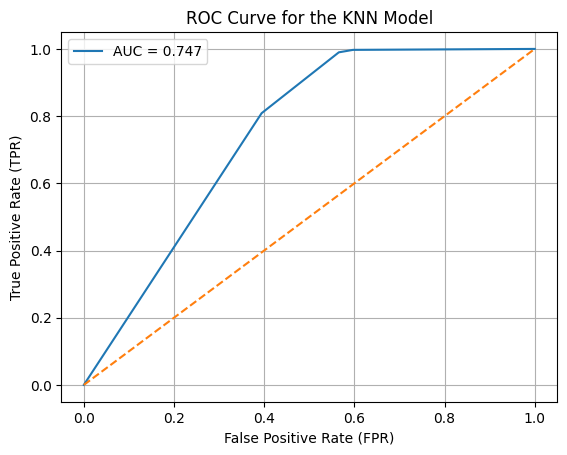

In [71]:
# Plotting the ROC curve (with AUC label)
plt.plot(knn_fpr, knn_tpr, label='AUC = {:.3f}'.format(knn_auc))
plt.plot([0, 1], [0, 1], '--')
plt.title('ROC Curve for the KNN Model')
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.legend()
plt.grid(True)
plt.show()